In [ ]:
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix


import time
from IPython.display import clear_output


In [ ]:

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/creditcard.csv')


In [ ]:

data.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:

print(f"Veri seti satır sayısı: {data.shape[0]}, Sütun sayısı: {data.shape[1]}")


Veri seti satır sayısı: 284807, Sütun sayısı: 31


In [ ]:
# Class distribution
print(data['Class'].value_counts())


Class
0    284315
1       492
Name: count, dtype: int64


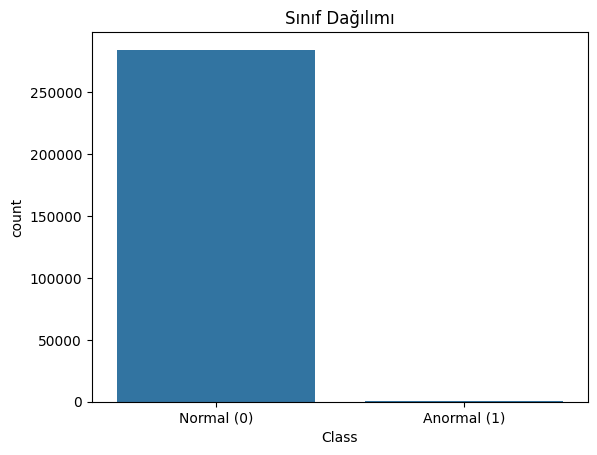

In [ ]:
# Visualizing class distribution
sns.countplot(x='Class', data=data)
plt.title('Sınıf Dağılımı')
plt.xticks([0, 1], ['Normal (0)', 'Anormal (1)'])
plt.show()


In [ ]:
# Standardize the 'Time' and 'Amount' columns
scaler = StandardScaler()
data['scaled_amount'] = scaler.fit_transform(data['Amount'].values.reshape(-1, 1))
data['scaled_time'] = scaler.fit_transform(data['Time'].values.reshape(-1, 1))


In [ ]:
# Remove original columns
data.drop(['Time', 'Amount'], axis=1, inplace=True)


In [ ]:
# Selecting normal operations
data_normal = data[data['Class'] == 0]

# Separating properties and target variable
X = data_normal.drop('Class', axis=1)
y = data_normal['Class']


In [ ]:
# Create the Isolation Forest model
model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)


model.fit(X)


IsolationForest(contamination=0.01, random_state=42)

In [ ]:

X_test = data.drop('Class', axis=1)
y_test = data['Class']


y_pred = model.predict(X_test)


y_pred = [1 if x == -1 else 0 for x in y_pred]


In [ ]:
# Classification report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.99      0.99    284315
           1       0.09      0.60      0.16       492

    accuracy                           0.99    284807
   macro avg       0.55      0.79      0.58    284807
weighted avg       1.00      0.99      0.99    284807



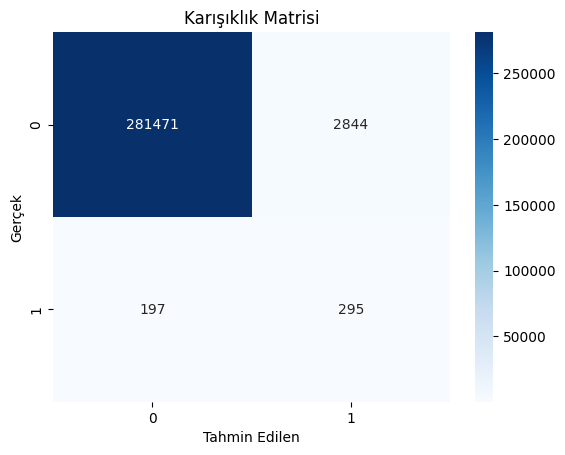

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Karışıklık Matrisi')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.show()


In [ ]:
# Shuffled data set
data_stream = data.sample(frac=1).reset_index(drop=True)

# Waiting time for simulation (seconds)
wait_time = 0.5

# A flag was created to check if the anomaly was detected
anomaly_detected = False

# Simulation started
for index, row in data_stream.iterrows():
    # Features received
    X_new = row.drop('Class').values.reshape(1, -1)
    # Actual value received
    y_true = row['Class']
    # Forecast was made
    y_pred = model.predict(X_new)
    y_pred = 1 if y_pred[0] == -1 else 0

    clear_output(wait=True)
    print(f"İşlem {index+1}")
    print(f"Gerçek Değer: {'Anormal' if y_true == 1 else 'Normal'}")
    print(f"Tahmin Edilen: {'Anormal' if y_pred == 1 else 'Normal'}")

    if y_pred == 1:
        print(">>> Uyarı: Anormal işlem tespit edildi!")
        anomaly_detected = True
        # Exited the loop when anomaly detected
        break
    else:
        print("İşlem normal.")

    time.sleep(wait_time)



İşlem 483
Gerçek Değer: Normal
Tahmin Edilen: Anormal
>>> Uyarı: Anormal işlem tespit edildi!
